# Task 14 — NLP Foundations — Text Classification

## Task Overview

This task focuses on Natural Language Processing (NLP) foundations for text classification. The objective is to build a machine learning system that can automatically classify movie reviews as positive or negative.

The task covers the complete NLP workflow, including text preprocessing, tokenization, stopword removal, stemming, lemmatization, Bag of Words (BoW), TF-IDF, word embeddings, traditional machine learning classifiers, and text-specific evaluation.

## Business Scenario

An e-commerce platform receives a large number of customer reviews every day. Manual review moderation is costly and time-consuming. An automated sentiment classification system can identify negative reviews and help prioritize them for urgent response.

## Objective

Build and evaluate an NLP-based binary sentiment classification system that can:

- Clean and preprocess raw review text
- Transform text into numerical representations using BoW and TF-IDF
- Apply text preprocessing techniques such as tokenization, stopword removal, stemming, and lemmatization
- Compare multiple traditional machine learning classifiers
- Explore word embeddings using Word2Vec
- Evaluate classification performance using relevant metrics
- Analyze errors using confusion matrices and per-class performance
- Interpret the results in the context of the business problem

## Key Skills

- Text preprocessing
- Tokenization
- Stopword removal
- Stemming
- Lemmatization
- Bag of Words (BoW)
- TF-IDF
- Word embeddings (Word2Vec)
- Traditional ML for text classification
- Model comparison
- Confusion matrix
- Per-class evaluation
- Business interpretation

## 1. Dataset Information

### Dataset Used

**IMDB Movie Reviews Dataset**

The dataset contains 50,000 movie reviews labeled for binary sentiment classification.

### Dataset Source

Kaggle — IMDB Dataset of 50K Movie Reviews

### Features

- `review`: Raw movie review text
- `sentiment`: Target variable containing `positive` or `negative`

### Target Variable

The target variable is `sentiment`.

- `positive` → Positive movie review
- `negative` → Negative movie review

### Dataset Size

The dataset contains 50,000 reviews with 2 columns.

### Why This Dataset?

The IMDB dataset is suitable for this task because it contains real-world natural language text with sentiment labels, making it appropriate for demonstrating the complete NLP text classification workflow.

## 2. Import Libraries

In this step, the required Python libraries are imported for data handling, visualization, text preprocessing, feature extraction, machine learning, and model evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

In this step, the IMDB Movie Reviews dataset is loaded into a pandas DataFrame.

The dataset contains movie reviews as raw text along with their corresponding sentiment labels. The `review` column will be used as the input text, while the `sentiment` column will be used as the target variable for binary sentiment classification.

The dataset will be loaded directly into the notebook using Google Colab's file upload option.

In [3]:
from google.colab import files
import io

uploaded = files.upload()

file_name = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully.")
print("File:", file_name)
print("Shape:", df.shape)

Saving IMDB Dataset.csv to IMDB Dataset.csv
Dataset loaded successfully.
File: IMDB Dataset.csv
Shape: (50000, 2)


## 4. Initial Dataset Inspection

In this step, the first few records of the dataset are examined to understand the structure and content of the review text and sentiment labels.

This helps verify that the dataset has been loaded correctly before performing any preprocessing.

In [4]:
display(df.head())

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 5. Dataset Structure and Data Types

In this step, the dataset shape, column names, and data types are examined.

This confirms the number of observations and features and verifies that the review text is stored as a textual data type and the sentiment label is stored correctly.

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (50000, 2)

Column Names:
['review', 'sentiment']

Data Types:
review       object
sentiment    object
dtype: object


### Observation

The dataset contains 50,000 movie reviews and 2 columns. The `review` column contains textual data, while `sentiment` contains the binary target labels. Since machine learning models require numerical input, the review text will later be transformed into numerical feature representations.

## 6. Missing Values and Duplicate Check

In this step, the dataset is checked for missing values and duplicate records.

Missing values can cause problems during preprocessing and model training, while duplicate reviews may introduce redundant information into the dataset.

In [6]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
review       0
sentiment    0
dtype: int64

Duplicate Rows:
418


### Observation

No missing values are present in the dataset. However, duplicate rows are present and will be removed before further preprocessing to reduce redundant observations and improve data quality.

## 7. Remove Duplicate Reviews

Duplicate reviews are removed to ensure that repeated records do not unnecessarily influence the learning process.

The index is reset after removing duplicates to maintain a clean sequential index.

In [7]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
duplicates_removed = rows_before - rows_after

print("Rows before removing duplicates:", rows_before)
print("Duplicate rows removed:", duplicates_removed)
print("Rows after removing duplicates:", rows_after)

Rows before removing duplicates: 50000
Duplicate rows removed: 418
Rows after removing duplicates: 49582


### Observation

A total of 418 duplicate rows were removed from the original 50,000 records. The cleaned dataset now contains 49,582 unique reviews. This provides a cleaner dataset for the subsequent NLP preprocessing and classification stages.

## 8. Sentiment Distribution

In this step, the distribution of positive and negative sentiment labels is analyzed.

Checking the target distribution is important because a highly imbalanced target can affect model training and evaluation. A visualization is also created to provide a clear view of the class distribution.

In [8]:
sentiment_counts = df["sentiment"].value_counts()

print("Sentiment Counts:")
print(sentiment_counts)

print("\nSentiment Percentages:")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

Sentiment Counts:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Sentiment Percentages:
sentiment
positive    50.19
negative    49.81
Name: proportion, dtype: float64


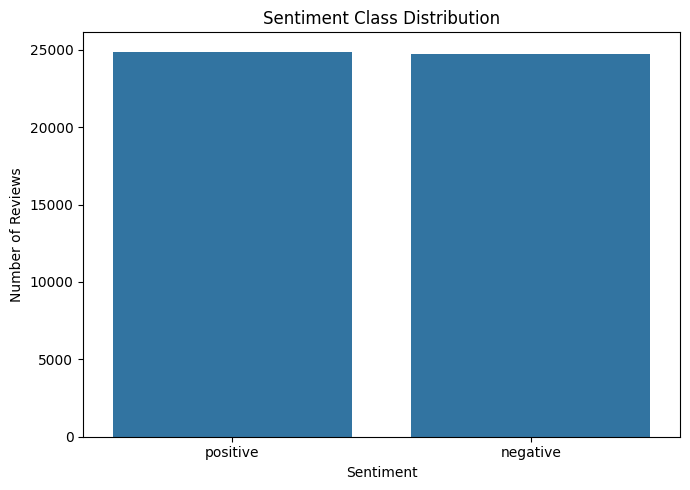

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

### Observation

The sentiment classes are almost evenly distributed, with 24,884 positive reviews (50.19%) and 24,698 negative reviews (49.81%). The small difference between the two classes indicates that the dataset is well balanced. Therefore, no additional class-balancing technique is required for model training.

## 9. Text Preprocessing

Raw movie reviews contain natural language elements such as HTML tags, punctuation, special characters, inconsistent capitalization, and common words.

In this section, the text will be progressively cleaned and transformed into a suitable format for NLP-based machine learning.

The original `review` column will be preserved, while preprocessing will be performed on a separate text column.

### 9.1 — Inspect Raw Review Text

Before cleaning the text, a few original reviews are examined to identify common patterns and noise that need to be handled during preprocessing.

In [10]:
for i in range(3):
    print(f"Review {i+1}:")
    print(df["review"].iloc[i])
    print("\n" + "-" * 100 + "\n")

Review 1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

### Observation

The raw reviews contain HTML tags such as `<br />`, uppercase and lowercase text, punctuation, and other textual elements. These observations confirm the need for text cleaning before applying NLP feature extraction and classification techniques.

### 9.2 — Create a Separate Text Column

A separate copy of the review text is created so that the original reviews remain unchanged.

This allows the preprocessing steps to be applied safely while preserving the original text for reference and comparison.

In [11]:
df["clean_review"] = df["review"].copy()

print("Original review:")
print(df["review"].iloc[0])

print("\nClean review column created successfully.")
print("Number of text records:", df["clean_review"].notna().sum())

Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

### 9.3 — Remove HTML Tags

HTML tags and markup are removed from the review text because they do not provide meaningful sentiment information for the classification model.

Regular expressions are used to identify and remove HTML tags while preserving the actual review content.

In [12]:
def remove_html(text):
    return re.sub(r"<.*?>", " ", text)

df["clean_review"] = df["clean_review"].apply(remove_html)

print("Text after HTML tag removal:")
print(df["clean_review"].iloc[0])

Text after HTML tag removal:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.  The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.  It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.  I would say the main appeal of the show is due to the fact

### 9.4 — Convert Text to Lowercase

All review text is converted to lowercase to maintain consistency.

Without this transformation, words such as `Good`, `good`, and `GOOD` may be treated as different tokens even though they have the same meaning.

In [13]:
df["clean_review"] = df["clean_review"].str.lower()

print("Text after lowercase conversion:")
print(df["clean_review"].iloc[0])

Text after lowercase conversion:
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.  the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.  it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.  i would say the main appeal of the show is due to the 

### 9.5 — Remove Punctuation and Special Characters

Punctuation and unnecessary special characters are removed to reduce noise in the textual representation.

Alphabetic characters and spaces are retained so that meaningful words remain available for subsequent NLP processing.

In [14]:
def remove_punctuation(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_review"] = df["clean_review"].apply(remove_punctuation)

print("Text after punctuation and special-character removal:")
print(df["clean_review"].iloc[0])

Text after punctuation and special-character removal:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it

### 9.6 — Compare Original and Cleaned Text

The original and cleaned versions of a review are compared to verify that unwanted HTML tags, capitalization differences, punctuation, and special characters have been removed while the main textual content is preserved.

In [15]:
print("ORIGINAL REVIEW:")
print(df["review"].iloc[0])

print("\n" + "=" * 100 + "\n")

print("CLEANED REVIEW:")
print(df["clean_review"].iloc[0])

ORIGINAL REVIEW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

### Observation

The comparison confirms that the preprocessing steps successfully removed HTML tags, converted the text to lowercase, and removed punctuation and special characters. The meaningful content of the reviews was retained, producing a cleaner text representation for subsequent NLP processing.

## 10. Tokenization

Tokenization is the process of breaking text into smaller units called tokens, usually individual words.

For example, the sentence:

"This movie was amazing"

is converted into:

["This", "movie", "was", "amazing"]

Tokenization is an important NLP preprocessing step because subsequent techniques such as stopword removal, stemming, and lemmatization operate on individual tokens.

In [16]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

df["tokens"] = df["clean_review"].apply(word_tokenize)

print("Original Review:")
print(df["clean_review"].iloc[0][:300])

print("\nTokenized Review:")
print(df["tokens"].iloc[0][:30])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original Review:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not 

Tokenized Review:
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'you', 'll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'the', 'first']


### Observation

The review text was successfully divided into individual word-level tokens. Tokenization converts continuous text into manageable units, enabling subsequent NLP operations such as stopword removal, stemming, and lemmatization.

## 11. Stopword Removal

Stopwords are common words such as `the`, `is`, `of`, and `and` that usually provide limited information for text classification.

Removing these words reduces unnecessary text and allows the model to focus more on informative words.

In this step, NLTK's English stopword list is used to remove common stopwords from the tokenized reviews.

In [17]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

df["filtered_tokens"] = df["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

print("Original Tokens:")
print(df["tokens"].iloc[0][:30])

print("\nTokens After Stopword Removal:")
print(df["filtered_tokens"].iloc[0][:30])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Original Tokens:
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'you', 'll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'the', 'first']

Tokens After Stopword Removal:
['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches']


## 12. Stemming

Stemming reduces words to their root-like form by removing common word endings.

For example, words such as `playing`, `played`, and `plays` may be reduced to a common stem such as `play`.

In this step, the Porter Stemmer is applied to the tokens after stopword removal. Stemming helps reduce variations of the same word and can make the text representation more compact.

In [18]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["stemmed_tokens"] = df["filtered_tokens"].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

print("Tokens After Stopword Removal:")
print(df["filtered_tokens"].iloc[0][:30])

print("\nTokens After Stemming:")
print(df["stemmed_tokens"].iloc[0][:30])

Tokens After Stopword Removal:
['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches']

Tokens After Stemming:
['one', 'review', 'mention', 'watch', 'oz', 'episod', 'hook', 'right', 'exactli', 'happen', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'heart', 'timid', 'show', 'pull', 'punch']


## 13. Lemmatization

Lemmatization reduces words to their meaningful dictionary base form, known as a lemma.

Unlike stemming, lemmatization considers valid word forms and produces more meaningful results. For example, words such as `reviews` and `watching` can be reduced to `review` and `watch`.

In this step, WordNet Lemmatizer is applied to the tokens after stopword removal. Lemmatization is compared with stemming to understand the effect of different text normalization techniques.

In [19]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

df["lemmatized_tokens"] = df["filtered_tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

print("Tokens After Stemming:")
print(df["stemmed_tokens"].iloc[0][:30])

print("\nTokens After Lemmatization:")
print(df["lemmatized_tokens"].iloc[0][:30])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Tokens After Stemming:
['one', 'review', 'mention', 'watch', 'oz', 'episod', 'hook', 'right', 'exactli', 'happen', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'heart', 'timid', 'show', 'pull', 'punch']

Tokens After Lemmatization:
['one', 'reviewer', 'mentioned', 'watching', 'oz', 'episode', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pull', 'punch']


## 14. Create Final Preprocessed Text

After completing tokenization, stopword removal, stemming, and lemmatization, the lemmatized tokens are converted back into text.

The lemmatized representation is selected for the final preprocessing pipeline because it produces more meaningful word forms than stemming.

This processed text will be used for the subsequent Bag-of-Words and TF-IDF feature extraction techniques.

In [20]:
df["processed_text"] = df["lemmatized_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

print("Final preprocessed text created successfully.")

Final preprocessed text created successfully.


## 15. Train-Test Split

The dataset is divided into training and testing sets before feature extraction.

The training set is used to learn the text representation and train the classification models, while the testing set is kept separate for final evaluation.

Stratified splitting is used to maintain a similar distribution of positive and negative sentiments in both sets.

This separation also helps prevent data leakage during feature extraction.

In [21]:
X = df["processed_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Training samples: 39665
Testing samples: 9917

Training sentiment distribution:
sentiment
positive    19907
negative    19758
Name: count, dtype: int64

Testing sentiment distribution:
sentiment
positive    4977
negative    4940
Name: count, dtype: int64


### Observation

The dataset was successfully divided into training and testing sets using stratified splitting. A total of 39,665 reviews were used for training and 9,917 reviews were reserved for testing.

The positive and negative sentiment classes remain well balanced in both sets. The training set contains 19,907 positive and 19,758 negative reviews, while the testing set contains 4,977 positive and 4,940 negative reviews.

This balanced distribution helps provide a reliable evaluation of the classification models. Keeping the test data separate also prevents information from the test set from influencing feature extraction or model training.

## 16. TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert the preprocessed review text into numerical features that machine learning models can understand.

TF-IDF assigns higher importance to words that are frequent in a particular review but less frequent across the complete collection of reviews.

The vectorizer is fitted only on the training data and then applied to the testing data. This prevents test-set information from influencing the learned vocabulary and avoids data leakage.

Unigrams and bigrams are considered to capture both individual words and meaningful two-word combinations.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

Training TF-IDF shape: (39665, 5000)
Testing TF-IDF shape: (9917, 5000)
Vocabulary size: 5000


### Observation

TF-IDF successfully converted the text reviews into numerical feature representations. Both the training and testing sets were transformed into 5,000 features.

The same learned vocabulary was used for both sets, with the vectorizer fitted only on the training data. This preserves the separation between training and testing data and prevents data leakage.

Using unigrams and bigrams allows the representation to capture both individual words and meaningful two-word combinations that may help distinguish positive and negative sentiment.

## 17. Bag of Words (BoW) Representation

Bag of Words (BoW) is another text representation technique that converts text into numerical features based on word occurrence counts.

Unlike TF-IDF, BoW does not assign importance weights based on how common a word is across the complete dataset. Instead, it records how frequently each vocabulary term appears in a document.

BoW provides a simple baseline text representation and allows comparison with the TF-IDF approach.

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("Training BoW shape:", X_train_bow.shape)
print("Testing BoW shape:", X_test_bow.shape)
print("Vocabulary size:", len(bow_vectorizer.vocabulary_))

Training BoW shape: (39665, 5000)
Testing BoW shape: (9917, 5000)
Vocabulary size: 5000


### Observation

The Bag of Words representation was successfully created using the training and testing text data. Both datasets were converted into 5,000 numerical features using the same learned vocabulary.

The BoW representation captures the frequency of words and word combinations within each review. This representation will provide a useful comparison with TF-IDF when evaluating the classification models.

## 18. Word2Vec Word Embeddings

Word2Vec is used to learn dense numerical representations of words based on their surrounding context.

Unlike Bag of Words and TF-IDF, which mainly represent word occurrence or importance, Word2Vec captures relationships between words by learning from their contextual usage.

The preprocessed reviews are tokenized into word sequences and used to train a Word2Vec model. These learned embeddings provide a semantic representation of the vocabulary and complement the sparse BoW and TF-IDF representations.

In [24]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 58.9 MB/s eta 0:00:00


In [25]:
import gensim

print("Gensim version:", gensim.__version__)

Gensim version: 4.4.0


In [26]:
from gensim.models import Word2Vec

# Convert each review into a list of tokens
train_tokens = [text.split() for text in X_train]

print("Number of training reviews:", len(train_tokens))
print("Example tokenized review:")
print(train_tokens[0][:20])

Number of training reviews: 39665
Example tokenized review:
['one', 'jehovah', 'witness', 'also', 'work', 'acute', 'care', 'medical', 'facility', 'year', 'seen', 'people', 'die', 'hemolytic', 'reaction', 'blood', 'transfusion', 'attended', 'numerous', 'conference']


### 18.2 Train Word2Vec Model

The tokenized training reviews are used to train a Word2Vec model.

The model learns a dense vector representation for each word based on the words that appear around it. A 100-dimensional embedding space is used to capture useful semantic and contextual relationships between words.

The model is trained only on the training reviews to maintain a clear separation from the test data.

In [27]:
word2vec_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=2,
    sg=1,
    epochs=3,
    seed=42
)

print("Vocabulary size:", len(word2vec_model.wv))
print("Embedding dimension:", word2vec_model.vector_size)

Vocabulary size: 50345
Embedding dimension: 100


In [28]:
# Display sample vocabulary words
sample_words = list(word2vec_model.wv.index_to_key[:10])

print("Sample vocabulary words:")
print(sample_words)

# Check the vector of the first word
word = sample_words[0]

print("\nSelected word:", word)
print("Word vector:")
print(word2vec_model.wv[word])

print("\nVector shape:")
print(word2vec_model.wv[word].shape)

Sample vocabulary words:
['movie', 'film', 'one', 'like', 'time', 'good', 'character', 'story', 'even', 'would']

Selected word: movie
Word vector:
[ 1.07508510e-01  1.01128727e-01  2.16574743e-01 -1.14921428e-01
 -1.20468244e-01  5.37169397e-01 -3.03528439e-02  6.18213892e-01
 -4.76057738e-01 -1.96991116e-01 -4.56775188e-01  1.15964659e-01
  3.89537394e-01  5.82774341e-01  1.34651735e-01  2.05127262e-02
  3.84707265e-02 -4.09176707e-01 -3.58213633e-01  2.81524450e-01
 -4.82008271e-02  1.31146759e-01  1.05596840e-01  2.94574410e-01
  1.02730982e-01 -1.85939223e-01 -6.13359630e-01 -1.40684903e-01
 -1.67886719e-01 -3.81429791e-02 -1.32854372e-01 -1.17968343e-01
 -1.97926909e-01 -5.38846664e-02 -4.47385828e-05 -3.11684400e-01
  2.63173252e-01 -3.94609243e-01  2.93678157e-02  1.57684579e-01
 -4.53397632e-02 -2.85996914e-01  1.05440676e-01 -7.52113014e-02
 -1.89324439e-01  2.52243727e-01  1.15412951e-01  1.79755077e-01
  6.01865590e-01 -6.66829050e-02  5.02480252e-04 -4.56238985e-01
  1.474

In [29]:
word = "movie"

if word in word2vec_model.wv:
    print(f"Most similar words to '{word}':")
    similar_words = word2vec_model.wv.most_similar(word, topn=10)

    for similar_word, similarity in similar_words:
        print(f"{similar_word}: {similarity:.4f}")
else:
    print(f"'{word}' not found in vocabulary.")

Most similar words to 'movie':
film: 0.9196
definately: 0.8537
wasnt: 0.8472
baseketball: 0.8396
demonicus: 0.8365
caddyshack: 0.8336
ive: 0.8327
wholeheartedly: 0.8295
definetly: 0.8295
defiantly: 0.8281


### Observation

Word2Vec successfully learned word embeddings from the training reviews. The model learned a vocabulary of 50,345 words, with each word represented by a 100-dimensional vector.

The learned vector for `movie` confirmed that each word is represented numerically, while the similarity analysis showed that words such as `film` had a high contextual similarity with `movie`. This demonstrates that Word2Vec can learn relationships between words based on their usage in the review dataset.

Overall, Word2Vec provides a dense, context-based representation that complements the sparse BoW and TF-IDF representations used earlier.

## 19. Document-Level Word2Vec Features

Word2Vec generates an embedding for each individual word, while the sentiment classifier requires one numerical representation for each complete review.

To create document-level features, the Word2Vec vectors of all words in each review are averaged. This produces one fixed-length 100-dimensional vector for every review.

The same trained Word2Vec model is used to transform both training and testing reviews.

In [30]:
import numpy as np

def document_embedding(text, model):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_train_w2v = np.array([
    document_embedding(text, word2vec_model)
    for text in X_train
])

X_test_w2v = np.array([
    document_embedding(text, word2vec_model)
    for text in X_test
])

print("Training Word2Vec feature shape:", X_train_w2v.shape)
print("Testing Word2Vec feature shape:", X_test_w2v.shape)

Training Word2Vec feature shape: (39665, 100)
Testing Word2Vec feature shape: (9917, 100)


### Observation

The trained Word2Vec embeddings were successfully converted into document-level features by averaging the word vectors within each review. Each review is now represented by a fixed-length 100-dimensional vector.

The training set contains 39,665 document embeddings, while the testing set contains 9,917 document embeddings. These dense features can now be used as input for traditional machine learning classifiers.

## 20. Baseline Text Classification

Logistic Regression is used as the baseline classifier for sentiment classification. It is a strong and efficient traditional machine learning algorithm for high-dimensional text data.

The baseline model is trained using TF-IDF features and evaluated on the unseen testing data. Its performance will provide a reference point for comparing other classifiers and text representations.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

y_pred_baseline = baseline_model.predict(X_test_tfidf)

print("Baseline Logistic Regression Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_baseline), 4))
print("Precision:", round(precision_score(y_test, y_pred_baseline, pos_label="positive"), 4))
print("Recall   :", round(recall_score(y_test, y_pred_baseline, pos_label="positive"), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_baseline, pos_label="positive"), 4))

Baseline Logistic Regression Results
Accuracy : 0.8909
Precision: 0.8825
Recall   : 0.9028
F1-Score : 0.8925


Confusion Matrix:
[[4342  598]
 [ 484 4493]]


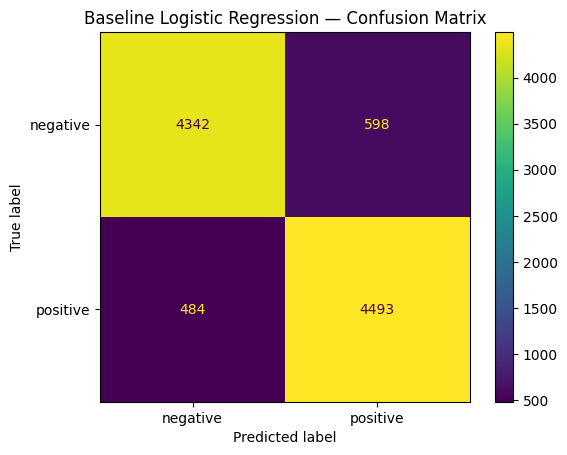

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_baseline,
    labels=["negative", "positive"]
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("Baseline Logistic Regression — Confusion Matrix")
plt.show()

### Observation

The confusion matrix shows that the baseline Logistic Regression model correctly classified 4,342 negative reviews and 4,493 positive reviews.

A total of 598 negative reviews were incorrectly classified as positive, while 484 positive reviews were incorrectly classified as negative. The relatively balanced errors across both sentiment classes indicate that the baseline model performs consistently for positive and negative reviews.

## 21. Naive Bayes Text Classification

Naive Bayes is a probabilistic machine learning algorithm that is well suited for text classification tasks. It estimates the probability of each sentiment class based on the observed text features.

The Multinomial Naive Bayes classifier is trained using the TF-IDF representation and evaluated on the unseen testing data. Its performance will be compared with the Logistic Regression baseline.

In [33]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_nb), 4))
print("Precision:", round(precision_score(y_test, y_pred_nb, pos_label="positive"), 4))
print("Recall   :", round(recall_score(y_test, y_pred_nb, pos_label="positive"), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_nb, pos_label="positive"), 4))

Naive Bayes Results
Accuracy : 0.8601
Precision: 0.8507
Recall   : 0.8748
F1-Score : 0.8626


Naive Bayes Confusion Matrix:
[[4176  764]
 [ 623 4354]]


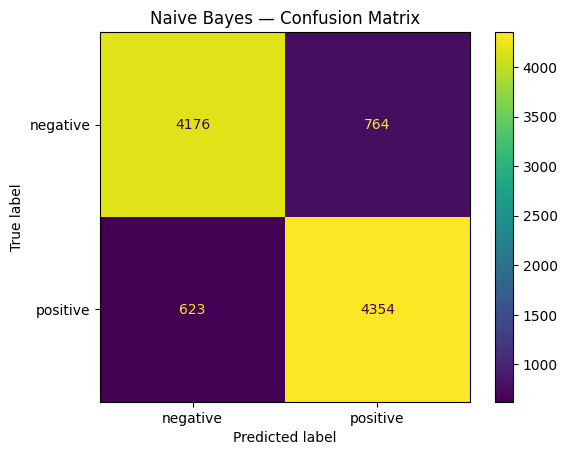

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["negative", "positive"]
)

print("Naive Bayes Confusion Matrix:")
print(cm_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("Naive Bayes — Confusion Matrix")
plt.show()

### Observation

The Naive Bayes model correctly classified 4,176 negative reviews and 4,354 positive reviews.

It incorrectly classified 764 negative reviews as positive and 623 positive reviews as negative. The model achieved an accuracy of 86.01% and an F1-score of 86.26%, which is lower than the Logistic Regression baseline. Therefore, Logistic Regression currently provides better performance for the TF-IDF representation.

## 22. Linear SVM Classification

Linear Support Vector Machine (SVM) is a strong traditional machine learning algorithm for text classification. It works effectively with high-dimensional sparse representations such as TF-IDF.

The Linear SVM classifier is trained using the TF-IDF features and evaluated on the unseen testing data. Its performance is compared with the Logistic Regression and Naive Bayes models.

In [35]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_svm), 4))
print("Precision:", round(precision_score(y_test, y_pred_svm, pos_label="positive"), 4))
print("Recall   :", round(recall_score(y_test, y_pred_svm, pos_label="positive"), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_svm, pos_label="positive"), 4))

Linear SVM Results
Accuracy : 0.8834
Precision: 0.8805
Recall   : 0.8883
F1-Score : 0.8844


Linear SVM Confusion Matrix:
[[4340  600]
 [ 556 4421]]


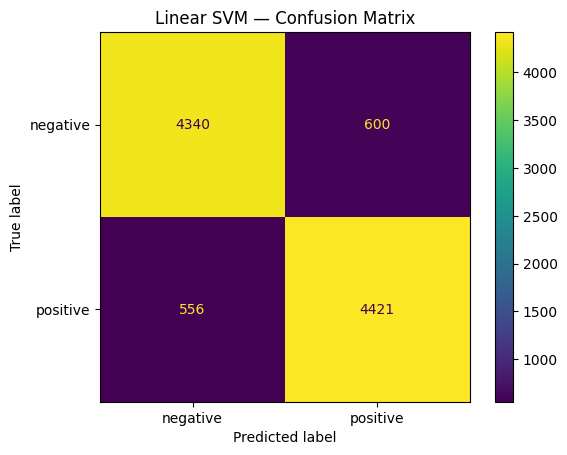

In [36]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=["negative", "positive"]
)

print("Linear SVM Confusion Matrix:")
print(cm_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("Linear SVM — Confusion Matrix")
plt.show()

### Observation

The Linear SVM model correctly classified 4,340 negative reviews and 4,421 positive reviews.

It incorrectly classified 600 negative reviews as positive and 556 positive reviews as negative. The model achieved 88.34% accuracy and an F1-score of 88.44%, which is better than Naive Bayes but slightly lower than the Logistic Regression baseline.

## 23. Model Comparison

The performance of Logistic Regression, Naive Bayes, and Linear SVM is compared using accuracy, precision, recall, and F1-score.

All models were trained and evaluated using the same TF-IDF representation and the same training and testing sets.

In [37]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline, pos_label="positive"),
        precision_score(y_test, y_pred_nb, pos_label="positive"),
        precision_score(y_test, y_pred_svm, pos_label="positive")
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline, pos_label="positive"),
        recall_score(y_test, y_pred_nb, pos_label="positive"),
        recall_score(y_test, y_pred_svm, pos_label="positive")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_baseline, pos_label="positive"),
        f1_score(y_test, y_pred_nb, pos_label="positive"),
        f1_score(y_test, y_pred_svm, pos_label="positive")
    ]
})

model_comparison = model_comparison.round(4)

print(model_comparison)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8909     0.8825  0.9028    0.8925
1          Naive Bayes    0.8601     0.8507  0.8748    0.8626
2           Linear SVM    0.8834     0.8805  0.8883    0.8844


### Observation

Logistic Regression achieved the best overall performance with 89.09% accuracy and an F1-score of 89.25%. Linear SVM followed with 88.34% accuracy and an F1-score of 88.44%, while Naive Bayes achieved 86.01% accuracy and an F1-score of 86.26%.

Therefore, Logistic Regression is currently the best-performing classifier with the TF-IDF representation. However, its accuracy is still slightly below the 90% business target, so other text representations and model configurations will be evaluated next.

## 24. Bag of Words Classification

Logistic Regression is evaluated using the Bag of Words representation to compare its performance with the TF-IDF-based model.

The same training and testing split is used to ensure a fair comparison between the two text representations.

In [38]:
bow_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

bow_lr_model.fit(X_train_bow, y_train)

y_pred_bow_lr = bow_lr_model.predict(X_test_bow)

print("Bag of Words + Logistic Regression Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_bow_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_bow_lr, pos_label="positive"), 4))
print("Recall   :", round(recall_score(y_test, y_pred_bow_lr, pos_label="positive"), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_bow_lr, pos_label="positive"), 4))

Bag of Words + Logistic Regression Results
Accuracy : 0.8777
Precision: 0.8781
Recall   : 0.8782
F1-Score : 0.8782


Bag of Words + Logistic Regression Confusion Matrix:
[[4333  607]
 [ 606 4371]]


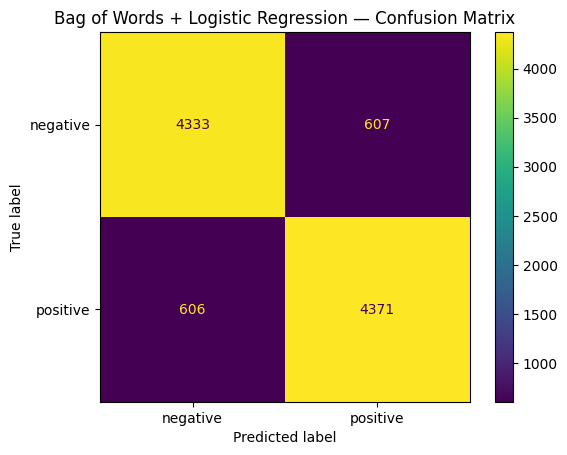

In [39]:
cm_bow = confusion_matrix(
    y_test,
    y_pred_bow_lr,
    labels=["negative", "positive"]
)

print("Bag of Words + Logistic Regression Confusion Matrix:")
print(cm_bow)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bow,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("Bag of Words + Logistic Regression — Confusion Matrix")
plt.show()

### Observation

The Bag of Words + Logistic Regression model correctly classified 4,333 negative reviews and 4,371 positive reviews.

It incorrectly classified 607 negative reviews as positive and 606 positive reviews as negative. The model achieved 87.77% accuracy and an F1-score of 87.82%.

Compared with TF-IDF + Logistic Regression, the Bag of Words representation performed slightly worse. This indicates that TF-IDF provides more useful feature weighting for sentiment classification in this dataset.

## 25. Word2Vec-Based Classification

The document-level Word2Vec embeddings are evaluated using Logistic Regression.

Each review is represented by a 100-dimensional dense vector obtained by averaging the Word2Vec vectors of its words. The same Logistic Regression classifier is used to provide a fair comparison with the TF-IDF and Bag of Words representations.

In [40]:
w2v_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

w2v_lr_model.fit(X_train_w2v, y_train)

y_pred_w2v_lr = w2v_lr_model.predict(X_test_w2v)

print("Word2Vec + Logistic Regression Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_w2v_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_w2v_lr, pos_label="positive"), 4))
print("Recall   :", round(recall_score(y_test, y_pred_w2v_lr, pos_label="positive"), 4))
print("F1-Score :", round(f1_score(y_test, y_pred_w2v_lr, pos_label="positive"), 4))

Word2Vec + Logistic Regression Results
Accuracy : 0.8684
Precision: 0.862
Recall   : 0.8784
F1-Score : 0.8701


Word2Vec + Logistic Regression Confusion Matrix:
[[4240  700]
 [ 605 4372]]


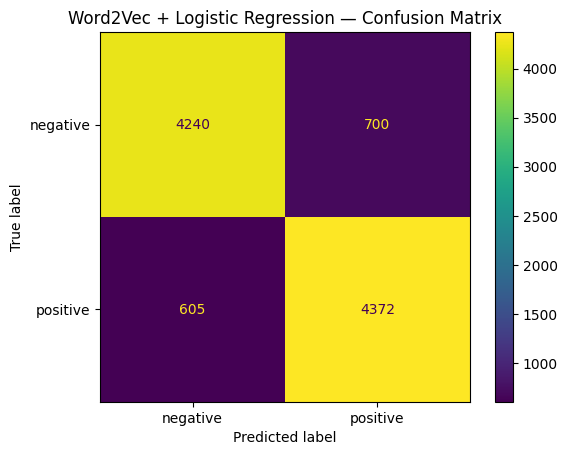

In [41]:
cm_w2v = confusion_matrix(
    y_test,
    y_pred_w2v_lr,
    labels=["negative", "positive"]
)

print("Word2Vec + Logistic Regression Confusion Matrix:")
print(cm_w2v)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_w2v,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("Word2Vec + Logistic Regression — Confusion Matrix")
plt.show()

### Observation

The Word2Vec + Logistic Regression model correctly classified 4,240 negative reviews and 4,372 positive reviews.

It incorrectly classified 700 negative reviews as positive and 605 positive reviews as negative. The model achieved 86.84% accuracy and an F1-score of 87.01%.

Compared with TF-IDF and Bag of Words, the Word2Vec representation performed worse for this sentiment classification task.

## 26. Text Representation Comparison

The three text representations are compared using the same Logistic Regression classifier to determine which representation performs best for sentiment classification.

In [42]:
representation_comparison = pd.DataFrame({
    "Representation": [
        "TF-IDF",
        "Bag of Words",
        "Word2Vec"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_bow_lr),
        accuracy_score(y_test, y_pred_w2v_lr)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline, pos_label="positive"),
        precision_score(y_test, y_pred_bow_lr, pos_label="positive"),
        precision_score(y_test, y_pred_w2v_lr, pos_label="positive")
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline, pos_label="positive"),
        recall_score(y_test, y_pred_bow_lr, pos_label="positive"),
        recall_score(y_test, y_pred_w2v_lr, pos_label="positive")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_baseline, pos_label="positive"),
        f1_score(y_test, y_pred_bow_lr, pos_label="positive"),
        f1_score(y_test, y_pred_w2v_lr, pos_label="positive")
    ]
})

representation_comparison = representation_comparison.round(4)

print(representation_comparison)

  Representation  Accuracy  Precision  Recall  F1-Score
0         TF-IDF    0.8909     0.8825  0.9028    0.8925
1   Bag of Words    0.8777     0.8781  0.8782    0.8782
2       Word2Vec    0.8684     0.8620  0.8784    0.8701


### Observation

TF-IDF achieved the best performance across all three text representations, with 89.09% accuracy and an F1-score of 89.25%.

Bag of Words achieved 87.77% accuracy, while Word2Vec achieved 86.84%. Therefore, TF-IDF provides the most effective representation for this sentiment classification task when combined with Logistic Regression.

The results also show that traditional sparse text representations performed better than the averaged Word2Vec representation for this dataset.

## 27. Final Model Evaluation

Based on the model and representation comparisons, TF-IDF with Logistic Regression is selected as the final model because it achieved the highest accuracy and F1-score.

A detailed classification report is used to evaluate the final model for each sentiment class.

In [43]:
from sklearn.metrics import classification_report

print("Final Model: TF-IDF + Logistic Regression")
print()

print(classification_report(
    y_test,
    y_pred_baseline,
    labels=["negative", "positive"],
    digits=4
))

Final Model: TF-IDF + Logistic Regression

              precision    recall  f1-score   support

    negative     0.8997    0.8789    0.8892      4940
    positive     0.8825    0.9028    0.8925      4977

    accuracy                         0.8909      9917
   macro avg     0.8911    0.8909    0.8909      9917
weighted avg     0.8911    0.8909    0.8909      9917



### Observation

The final TF-IDF + Logistic Regression model achieved 89.09% accuracy and a weighted F1-score of 89.09%.

For negative reviews, the model achieved 89.97% precision and 87.89% recall. For positive reviews, it achieved 88.25% precision and 90.28% recall.

The results show balanced performance across both sentiment classes, with slightly higher recall for positive reviews. Overall, the model provides strong sentiment classification performance but remains slightly below the required 90% accuracy target.

## 28. Final Model Confusion Matrix

The confusion matrix of the selected TF-IDF + Logistic Regression model is reviewed to examine the correct and incorrect predictions for both sentiment classes.

Final Model Confusion Matrix:
[[4342  598]
 [ 484 4493]]


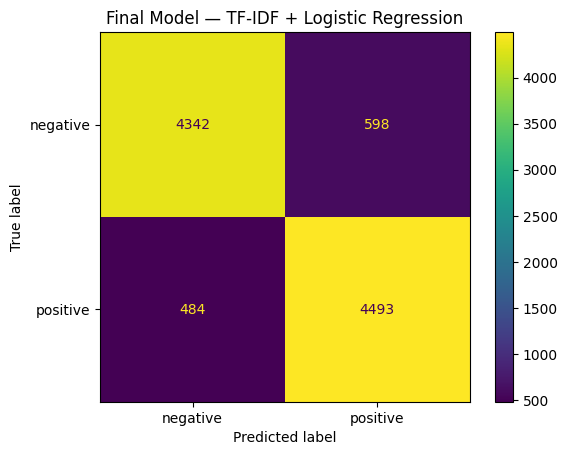

In [44]:
cm_final = confusion_matrix(
    y_test,
    y_pred_baseline,
    labels=["negative", "positive"]
)

print("Final Model Confusion Matrix:")
print(cm_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("Final Model — TF-IDF + Logistic Regression")
plt.show()

### Observation

The final model correctly classified 4,342 negative reviews and 4,493 positive reviews.

It misclassified 598 negative reviews as positive and 484 positive reviews as negative. The errors are relatively balanced between the two sentiment classes, supporting the overall reliability of the final model.

## 29. Model Performance Visualization

The performance of the evaluated classifiers is visualized using accuracy and F1-score. This provides a clear comparison of the models and helps identify the best-performing approach.

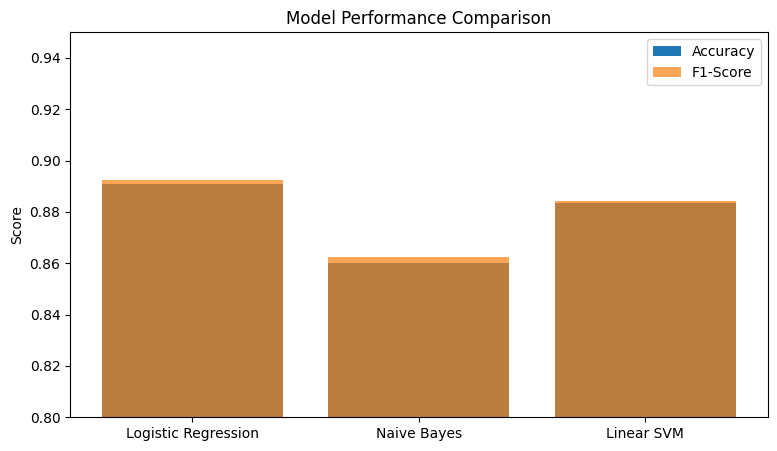

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"],
    label="Accuracy"
)

plt.bar(
    model_comparison["Model"],
    model_comparison["F1-Score"],
    alpha=0.7,
    label="F1-Score"
)

plt.ylim(0.80, 0.95)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

### Observation

Logistic Regression achieved the highest accuracy and F1-score among the three classifiers. Linear SVM performed slightly lower, while Naive Bayes showed the lowest performance.

The results confirm that Logistic Regression with TF-IDF provides the strongest overall performance among the evaluated models.

## 30. Save Final Visualizations

The key visualizations generated during the task are saved as PNG files for documentation and GitHub submission.

In [46]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create visualization folder
os.makedirs("visualizations", exist_ok=True)

# 1. Baseline Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
).plot(ax=ax)

ax.set_title("Baseline Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "visualizations/confusion_matrix_baseline_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)


# 2. Naive Bayes
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["negative", "positive"]
).plot(ax=ax)

ax.set_title("Naive Bayes — Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "visualizations/confusion_matrix_naive_bayes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)


# 3. Linear SVM
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["negative", "positive"]
).plot(ax=ax)

ax.set_title("Linear SVM — Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "visualizations/confusion_matrix_linear_svm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)


# 4. Final Model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["negative", "positive"]
).plot(ax=ax)

ax.set_title("Final Model — TF-IDF + Logistic Regression")
plt.tight_layout()
plt.savefig(
    "visualizations/confusion_matrix_final_model.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)


# 5. Model Performance Comparison
fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(model_comparison))

ax.bar(
    [i - 0.2 for i in x],
    model_comparison["Accuracy"],
    width=0.4,
    label="Accuracy"
)

ax.bar(
    [i + 0.2 for i in x],
    model_comparison["F1-Score"],
    width=0.4,
    label="F1-Score"
)

ax.set_xticks(list(x))
ax.set_xticklabels(model_comparison["Model"])
ax.set_ylim(0.80, 0.95)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()

plt.tight_layout()
plt.savefig(
    "visualizations/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

print("All important visualizations saved successfully.")
print("\nSaved files:")
for file in sorted(os.listdir("visualizations")):
    print("-", file)

All important visualizations saved successfully.

Saved files:
- confusion_matrix_baseline_logistic_regression.png
- confusion_matrix_final_model.png
- confusion_matrix_linear_svm.png
- confusion_matrix_naive_bayes.png
- model_performance_comparison.png


## 31. Final Results and Shortcomings

The final selected model is Logistic Regression with TF-IDF features. It achieved 89.09% accuracy and an F1-score of 89.25%.

Although the model provides strong and balanced sentiment classification, it does not reach the required 90% accuracy target. The main limitation is that traditional TF-IDF features do not fully capture contextual meaning, word order, sarcasm, or complex sentiment expressions.

The averaged Word2Vec representation also performed below TF-IDF, indicating that simple document-level averaging may lose important sentiment information.

## 32. Conclusion

This task developed an end-to-end sentiment classification pipeline using the IMDB movie review dataset.

The text was preprocessed and transformed using TF-IDF, Bag of Words, and Word2Vec. Multiple traditional classifiers were evaluated, including Logistic Regression, Naive Bayes, and Linear SVM.

TF-IDF with Logistic Regression achieved the best performance with 89.09% accuracy and an F1-score of 89.25%. The model showed balanced performance across positive and negative sentiment classes.

The results demonstrate that traditional machine learning can provide strong performance for large-scale text classification. However, the 90% business target was not fully achieved, leaving room for improvement through advanced NLP techniques and contextual language models.